In [1]:
%load_ext autoreload
%autoreload

In [2]:
import torch
import numpy as np

# from gromo.utils.tools import *
from low_rank_linear_regression import (
    value,
    solve_tiny,
    solve_tiny_normalized,
    solve_nih,
    solve_svd_l2,
    solve_svd_l2_tl,
)
from typing import Callable
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend("pytorch")

import warnings

warnings.filterwarnings("ignore")

I tested different methods to compute the new neuronns ie to solve:
$$\min_{A, O} ||Y - X A O||_F$$

- the one from the TINY paper (ie SVD of $S^{-1/2}N$ then multiply back with $S^{-1/2}N$)
- the simple SVD of $S^{-1}N$
- the one from https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4191838/pdf/nihms497477.pdf (i will call it SXYZ) which is basically getting the SVD of $X = UDV^T$ then extracting the first vectors from the SVD of $V D^{-1} U^T Y$ (and slight variation that do not seems to change much) (Note that this include the SVD of a matrix of size $n \times p$ where $n$ is the number of sample, the time complexity is still linear in $n$ but it is more expensive in practice. On an other point, this does not allow to compute the tensor $S$ by batch so $X$ should fit in memory)


I generated the data with $x_{i,j} \sim N(0, 1)$,  $a_{i,j} \sim N(0, 1)$, $O_{i, j} \sim N(0, 1)$ and $Y = X A O + N(0, 10^{-3})$.

If the number of sample is low ($n=20$ but $p=200$ (input size) and $d=100$ (output size)), the SXYZ give better results, then the TINY and finally the SVD. If the number of sample is high ($n=p\times d$) all the methods give the approximately the same results (even if the TINY is slightly worse).

In [3]:
def gen_data(
    n: int, p: int, d: int, k: int, seed: int | None = None, float_type=torch.float64
) -> tuple[torch.Tensor, torch.Tensor]:
    true_a = torch.randn(p, k, dtype=float_type)
    true_b = torch.randn(k, d, dtype=float_type)

    x = torch.randn(n, p, dtype=float_type)
    w = torch.randn(p, p, dtype=float_type)
    x = x @ w
    x *= 10 * torch.rand(p, dtype=float_type)
    y = x @ true_a @ true_b + (1e-3) * torch.randn(n, d, dtype=float_type)
    return x, y

In [4]:
def test_methods(
    n: int,
    p: int,
    d: int,
    k: int,
    methods: dict[
        str,
        Callable[[torch.Tensor, torch.Tensor, int], tuple[torch.Tensor, torch.Tensor]],
    ],
    samples: int = 100,
    float_type=torch.float64,
    gpu: bool = False,
):
    results = {name: np.zeros(samples) for name in methods.keys()}
    for i in range(samples):
        x, y = gen_data(n, p, d, k, seed=i, float_type=float_type)
        if gpu and torch.cuda.is_available():
            x = x.to(device=torch.device("cuda"))
            y = y.to(device=torch.device("cuda"))
        for name, method in methods.items():
            a, b = method(x, y, k)
            results[name][i] = value(x, y, a, b) / np.sqrt(n * p)
    return results

In [5]:
methods = {
    "TINY": solve_tiny,
    "TINY N": solve_tiny_normalized,
    "SXYZ": solve_nih,
    "SVD": solve_svd_l2,
    # "SVD tl": solve_svd_l2_tl,
    # "SVD pi": solve_svd_l2_pinv,
    # "SXYZ no proj": lambda x, y, k: solve_nih(x, y, k, option=1),
    # "SXYZ permute proj trunc": lambda x, y, k: solve_nih(x, y, k, option=2)
}

p = 100
d = 100
k = 1

In [6]:
agglomerate_results = dict()
gpu = False
for tf in [torch.float32, torch.float64]:
    for n in [20, 250, p * d, 10 * p * d]:
        results = test_methods(n, p, d, k, methods, float_type=tf, gpu=gpu)
        print(
            f"type: {tf}, n = {n}, p = {p}, d = {d}, k = {k}, device: {'GPU' if gpu and torch.cuda.is_available() else 'CPU'}"
        )
        print("-" * 10)
        results_avg = {name: res.mean() for name, res in results.items()}
        best_avg = min(results_avg.values())
        best_method = [name for name, res in results.items() if res.mean() == best_avg][
            0
        ]

        for name, res in results.items():
            print(
                f"{name}:\t\t{res.mean():.3e} (this / best = {res.mean() / best_avg:.1e}) {'(BEST)' if name == best_method else ''}"
            )
        print()
        agglomerate_results[(tf, n)] = results

type: torch.float32, n = 20, p = 100, d = 100, k = 1, device: CPU
----------
TINY:		3.167e-01 (this / best = 3.1e+02) 
TINY N:		3.141e-01 (this / best = 3.1e+02) 
SXYZ:		1.063e-03 (this / best = 1.0e+00) 
SVD:		1.021e-03 (this / best = 1.0e+00) (BEST)

type: torch.float32, n = 250, p = 100, d = 100, k = 1, device: CPU
----------
TINY:		1.357e-01 (this / best = 1.2e+02) 
TINY N:		1.310e-01 (this / best = 1.1e+02) 
SXYZ:		1.176e-03 (this / best = 1.0e+00) (BEST)
SVD:		4.114e-01 (this / best = 3.5e+02) 

type: torch.float32, n = 10000, p = 100, d = 100, k = 1, device: CPU
----------
TINY:		1.233e-01 (this / best = 9.4e+01) 
TINY N:		8.839e-02 (this / best = 6.8e+01) 
SXYZ:		1.309e-03 (this / best = 1.0e+00) (BEST)
SVD:		3.009e-01 (this / best = 2.3e+02) 

type: torch.float32, n = 100000, p = 100, d = 100, k = 1, device: CPU
----------
TINY:		8.644e-02 (this / best = 1.3e+01) 
TINY N:		8.313e-02 (this / best = 1.2e+01) 
SXYZ:		6.820e-03 (this / best = 1.0e+00) (BEST)
SVD:		3.347e-01 (this 

In [9]:
agglomerate_results = dict()
gpu = torch.cuda.is_available()
for tf in [torch.float32, torch.float64]:
    for n in [20, 250, p * d, 10 * p * d]:
        results = test_methods(n, p, d, k, methods, float_type=tf, gpu=gpu)
        print(
            f"type: {tf}, n = {n}, p = {p}, d = {d}, k = {k}, device: {'GPU' if gpu and torch.cuda.is_available() else 'CPU'}"
        )
        print("-" * 10)
        results_avg = {name: res.mean() for name, res in results.items()}
        best_avg = min(results_avg.values())
        best_method = [name for name, res in results.items() if res.mean() == best_avg][
            0
        ]

        for name, res in results.items():
            print(
                f"{name}:\t{res.mean():.3e} (this / best = {res.mean() / best_avg:.1e}) {'(BEST)' if name == best_method else ''}"
            )
        print()
        agglomerate_results[(tf, n)] = results

type: torch.float32, n = 20, p = 100, d = 100, k = 1, device: CPU
----------
TINY:	3.458e-01 (this / best = 3.4e+02) 
TINY N:	3.298e-01 (this / best = 3.2e+02) 
SXYZ:	1.060e-03 (this / best = 1.0e+00) 
SVD:	1.017e-03 (this / best = 1.0e+00) (BEST)

type: torch.float32, n = 250, p = 100, d = 100, k = 1, device: CPU
----------
TINY:	1.006e-01 (this / best = 8.6e+01) 
TINY N:	1.244e-01 (this / best = 1.1e+02) 
SXYZ:	1.165e-03 (this / best = 1.0e+00) (BEST)
SVD:	4.103e-01 (this / best = 3.5e+02) 

type: torch.float32, n = 10000, p = 100, d = 100, k = 1, device: CPU
----------
TINY:	1.191e-01 (this / best = 8.9e+01) 
TINY N:	1.584e-01 (this / best = 1.2e+02) 
SXYZ:	1.334e-03 (this / best = 1.0e+00) (BEST)
SVD:	3.176e-01 (this / best = 2.4e+02) 

type: torch.float32, n = 100000, p = 100, d = 100, k = 1, device: CPU
----------
TINY:	8.600e-02 (this / best = 1.2e+01) 
TINY N:	8.643e-01 (this / best = 1.2e+02) 
SXYZ:	7.089e-03 (this / best = 1.0e+00) (BEST)
SVD:	3.119e-01 (this / best = 4.4e+01

In [7]:
agglomerate_results = dict()
gpu = torch.cuda.is_available()
for tf in [torch.float32, torch.float64]:
    for n in [20, 250, p * d, 10 * p * d]:
        results = test_methods(n, p, d, k, methods, float_type=tf, gpu=gpu)
        print(
            f"type: {tf}, n = {n}, p = {p}, d = {d}, k = {k}, device: {'GPU' if gpu and torch.cuda.is_available() else 'CPU'}"
        )
        print("-" * 10)
        results_avg = {name: res.mean() for name, res in results.items()}
        best_avg = min(results_avg.values())
        best_method = [name for name, res in results.items() if res.mean() == best_avg][
            0
        ]

        for name, res in results.items():
            print(
                f"{name}:\t{res.mean():.3e} (this / best = {res.mean() / best_avg:.1e}) {'(BEST)' if name == best_method else ''}"
            )
        print()
        agglomerate_results[(tf, n)] = results

type: torch.float32, n = 20, p = 100, d = 100, k = 1, device: CPU
----------
TINY:	2.960e-01 (this / best = 2.9e+02) 
TINY N:	3.068e-01 (this / best = 3.0e+02) 
SXYZ:	1.058e-03 (this / best = 1.0e+00) 
SVD:	1.019e-03 (this / best = 1.0e+00) (BEST)

type: torch.float32, n = 250, p = 100, d = 100, k = 1, device: CPU
----------
TINY:	9.444e-02 (this / best = 8.2e+01) 
TINY N:	1.123e-01 (this / best = 9.7e+01) 
SXYZ:	1.158e-03 (this / best = 1.0e+00) (BEST)
SVD:	3.853e-01 (this / best = 3.3e+02) 

type: torch.float32, n = 10000, p = 100, d = 100, k = 1, device: CPU
----------
TINY:	9.764e-02 (this / best = 7.4e+01) 
TINY N:	1.641e-01 (this / best = 1.2e+02) 
SXYZ:	1.325e-03 (this / best = 1.0e+00) (BEST)
SVD:	2.728e-01 (this / best = 2.1e+02) 

type: torch.float32, n = 100000, p = 100, d = 100, k = 1, device: CPU
----------
TINY:	8.830e-02 (this / best = 1.3e+01) 
TINY N:	9.901e-01 (this / best = 1.4e+02) 
SXYZ:	6.995e-03 (this / best = 1.0e+00) (BEST)
SVD:	3.089e-01 (this / best = 4.4e+01

min: 4.29e-03, max: 7.46e+01


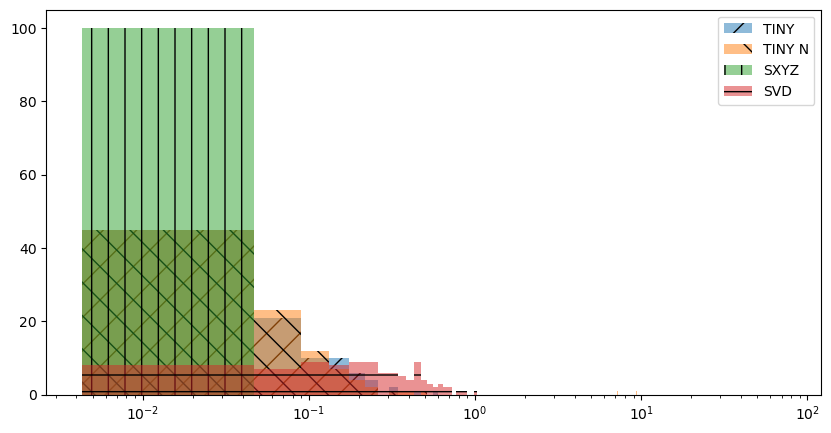

In [8]:
tf = torch.float32
n = 100000
results = agglomerate_results[(tf, n)]

# Plot histograms
# get the bins for all histograms
all_samples = np.concatenate([res for res in results.values()])
print(f"min: {all_samples.min():.2e}, max: {all_samples.max():.2e}")
bins = np.histogram_bin_edges(all_samples, bins="auto")
patterns = ["/", "\\", "|", "-", "+", "x", "o", "O", ".", "*"]


plt.figure(figsize=(10, 5))
for name, res in results.items():
    plt.hist(res, bins=bins, alpha=0.5, label=name, hatch=patterns.pop(0))
plt.xscale("log")
plt.legend()

In [9]:
p = 200
d = 200
k = 10
n = p * d
print(n)

x, y = gen_data(n, p, d, k)

40000


In [10]:
%%timeit
solve_tiny(x, y, k)

54.6 ms ± 7.22 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [11]:
%%timeit
solve_nih(x, y, k, option=1)

239 ms ± 22.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [12]:
%%timeit
solve_svd_l2(x, y, k)

50.1 ms ± 2.52 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [13]:
%%timeit
solve_svd_l2(x, y, k)

49.6 ms ± 1.38 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [14]:
%%timeit
solve_svd_l2_tl(x, y, k)

49.9 ms ± 2.65 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [15]:
p = 200
d = 200
k = 10
n = p * d
print(n)

x, y = gen_data(n, p, d, k)
x = x.to(device=torch.device("cuda"))
y = y.to(device=torch.device("cuda"))

40000


AssertionError: Torch not compiled with CUDA enabled

In [ ]:
%%timeit
solve_tiny(x, y, k)

In [ ]:
%%timeit
solve_nih(x, y, k, option=1)

In [ ]:
%%timeit
solve_svd_l2(x, y, k)

In [ ]:
%%timeit
solve_svd_l2_tl(x, y, k)